Importar librerías
- `Numpy`: cálculos vectoriales
- `Matplotlib.pyplot`: Ver los resultados
- `copy`: Para duplicar hábitats

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import copy
from scipy.special import comb

Definir las funciones de prueba $\mathcal{T}_1$ - $\mathcal{T}_6$ *(Zitzler et al.)*

In [2]:
# T1: Frente Convexo
def test_T1(x):
    m = len(x)
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (m - 1)
    h = 1.0 - np.sqrt(f1 / g)
    f2 = g * h
    return f1, f2

# T2: Frente No Convexo
def test_T2(x):
    m = len(x)
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (m - 1)
    h = 1.0 - (f1 / g)**2
    f2 = g * h
    return f1, f2

# T3: Frente Discreto
def test_T3(x):
    m = len(x)
    f1 = x[0]
    g = 1.0 + 9.0 * np.sum(x[1:]) / (m - 1)
    h = 1.0 - np.sqrt(f1 / g) - (f1 / g) * np.sin(10 * np.pi * f1)
    f2 = g * h
    return f1, f2

# T4: Frente Multimodal
def test_T4(x):
    m = len(x)
    f1 = x[0]
    g = 1.0 + 10.0 * (m - 1) + np.sum([xi**2 - 10.0 * np.cos(4 * np.pi * xi) for xi in x[1:]])
    h = 1.0 - np.sqrt(f1 / g)
    f2 = g * h
    return f1, f2

# T5: Frente Deceptivo (Bits)
def test_T5(x_list):
    u_x1 = np.sum(x_list[0])
    f1 = 1.0 + u_x1
    g = 0
    for i in range(1, len(x_list)):
        u_xi = np.sum(x_list[i])
        if u_xi < 5:
            v_u = 2.0 + u_xi
        else: # u_xi == 5
            v_u = 1.0
        g += v_u
    h = 1.0 / f1
    f2 = g * h
    return f1, f2

# T6: Frente No Uniforme
def test_T6(x):
    m = len(x)
    f1 = 1.0 - np.exp(-4 * x[0]) * (np.sin(6 * np.pi * x[0])**6)
    g = 1.0 + 9.0 * (np.sum(x[1:]) / (m - 1))**0.25
    h = 1.0 - (f1 / g)**2
    f2 = g * h
    return f1, f2

### Definir el "hábitat" (solucion)
Esta clase representa una solución individual (un hábitat). Almacena sus SIVs (la solución en sí), HSI (fitness) y las tasas de migración

In [3]:
class Habitat:
    def __init__(self, problem_type, m, bounds, bit_lengths=None):
        self.problem_type = problem_type
        self.m = m
        self.bounds = bounds
        self.bit_lengths = bit_lengths
        self.sivs = []
        if self.problem_type == 'float':
            self.low_bounds = np.array([b[0] for b in self.bounds])
            self.high_bounds = np.array([b[1] for b in self.bounds])
            self.sivs = np.random.uniform(self.low_bounds, self.high_bounds, size=self.m)
        elif self.problem_type == 'bits':
            self.sivs = [np.random.randint(0, 2, size=length) for length in self.bit_lengths]
        self.hsi = float('inf')
        self.lambda_ = 0.0
        self.mu = 0.0

    def clone(self):
        return copy.deepcopy(self)

Implemenar el algoritmo BBO

In [ ]:
def run_bbo(test_function, problem_type, m, bounds, bit_lengths,
            pop_size, generations, weights,
            max_migration, elitism_param, m_max): # Cambiado mutation_rate por m_max
    
    # 1. INICIALIZACIÓN
    poblacion = [Habitat(problem_type, m, bounds, bit_lengths) for _ in range(pop_size)]
    
    # --- Pre-cálculo para la Mutación Probabilística ---
    # S_max se toma como pop_size - 1 para que S vaya de 0 a pop_size-1
    S_max = pop_size - 1
    prob_species = np.zeros(S_max + 1)
    # Calcular Ps usando Eq. 12 (basado en binomiales, Eq. 8)
    # Ps = C(S_max, s) / 2^S_max
    total_combinations = 2**S_max
    for s_count in range(S_max + 1):
        # Usar comb(n, k) -> C(S_max, s_count)
        prob_species[s_count] = comb(S_max, s_count) / total_combinations

    # Encontrar P_max (probabilidad máxima)
    P_max = np.max(prob_species)

    # Bucle de Generaciones
    for gen in range(generations):
        
        # 2. CÁLCULO DE HSI (FITNESS)
        for hab in poblacion:
            f1, f2 = test_function(hab.sivs)
            hab.hsi = (weights[0] * f1) + (weights[1] * f2)
            
        # Ordenar población por HSI (mejor = menor HSI = índice 0)
        poblacion.sort(key=lambda h: h.hsi)
        
        # 3. ELITISMO
        elite_set = [hab.clone() for hab in poblacion[:elitism_param]]
        
        # 4. MAPEO DE TASAS
        ranks = np.arange(pop_size)
        # lambda decrece linealmente con el ranking (k=0 es el mejor)
        lambda_rates = max_migration * (1.0 - (ranks / pop_size))
        # mu crece linealmente con el ranking (k=0 es el mejor)
        mu_rates = max_migration * (ranks / pop_size)
        
        for k, hab in enumerate(poblacion):
            hab.lambda_ = lambda_rates[k]
            hab.mu = mu_rates[k]
            
        # 5. MIGRACIÓN
        new_poblacion = [] + elite_set # Empezar con la élite
        
        suma_mu = np.sum(mu_rates)
        prob_mu = mu_rates / suma_mu if suma_mu > 0 else np.full(pop_size, 1/pop_size)
        
        if problem_type == 'float':
            all_sivs = np.array([h.sivs for h in poblacion]) # Requerido para vectorización

        for i in range(elitism_param, pop_size):
            hab_modificado = poblacion[i].clone()

            if hab_modificado.problem_type == 'float':
                migrate_mask = np.random.rand(m) < hab_modificado.lambda_
                if not np.any(migrate_mask):
                    new_poblacion.append(hab_modificado)
                    continue
                donor_indices = np.random.choice(pop_size, size=m, p=prob_mu)
                donor_sivs = all_sivs[donor_indices, np.arange(m)]
                hab_modificado.sivs = np.where(migrate_mask, donor_sivs, hab_modificado.sivs)
                
            elif hab_modificado.problem_type == 'bits':
                for j in range(m):
                    if random.random() < hab_modificado.lambda_:
                        hab_donante = np.random.choice(poblacion, p=prob_mu)
                        hab_modificado.sivs[j] = copy.deepcopy(hab_donante.sivs[j])

            new_poblacion.append(hab_modificado)
        
        poblacion = new_poblacion

        # 6. MUTACIÓN (Basada en Probabilidad Ps)
        for i in range(elitism_param, pop_size): # No mutar la élite
            hab = poblacion[i]
            
            # Calcular S y la tasa de mutación m_k para este hábitat
            k = i # Índice/Ranking en la población ordenada (0 = mejor)
            # Mapeo Ranking (k) a Species Count (S): S = S_max - k
            # El mejor (k=0) tiene S=S_max; el peor (k=pop_size-1) tiene S=0
            species_count = S_max - k
            prob_s = prob_species[species_count]
            
            # Calcular tasa de mutación individual
            # m(S) = m_max * (1 - Ps / P_max)
            # Evitar división por cero si P_max es muy pequeño
            if P_max > 1e-9:
                 mutation_prob_hab = m_max * (1.0 - prob_s / P_max)
            else:
                 mutation_prob_hab = m_max # Mutación máxima si P_max es cero o muy bajo

            # Aplicar mutación a cada SIV con esta probabilidad individual
            if hab.problem_type == 'float':
                mutate_mask = np.random.rand(m) < mutation_prob_hab # Usar prob individual
                if not np.any(mutate_mask): # Saltar si no hay nada que mutar
                    continue
                random_sivs = np.random.uniform(hab.low_bounds, hab.high_bounds, size=m)
                hab.sivs = np.where(mutate_mask, random_sivs, hab.sivs)
                # No se necesita check_bounds() aquí
                
            elif hab.problem_type == 'bits':
                for j in range(m):
                    if random.random() < mutation_prob_hab: # Usar prob individual
                        # Asegurarse de que hay bits para voltear
                        if len(hab.sivs[j]) > 0:
                            bit_idx = random.randint(0, len(hab.sivs[j]) - 1)
                            hab.sivs[j][bit_idx] = 1 - hab.sivs[j][bit_idx] # Flip bit

    # --- FIN DEL BUCLE ---
    
    # 7. CÁLCULO FINAL Y RETORNO
    final_results = []
    for hab in poblacion:
        f1, f2 = test_function(hab.sivs)
        hsi_final = (weights[0] * f1) + (weights[1] * f2)
        final_results.append((f1, f2, hsi_final))
        
    final_results.sort(key=lambda x: x[2]) # Ordenar por HSI final
    
    return final_results[0][0], final_results[0][1] # Devolver el mejor (f1, f2)

# Ejecución y Gráfico

Test $\mathcal{T}_1$

Ejecutando BBO (con mutación probabilística) para test_T1...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0

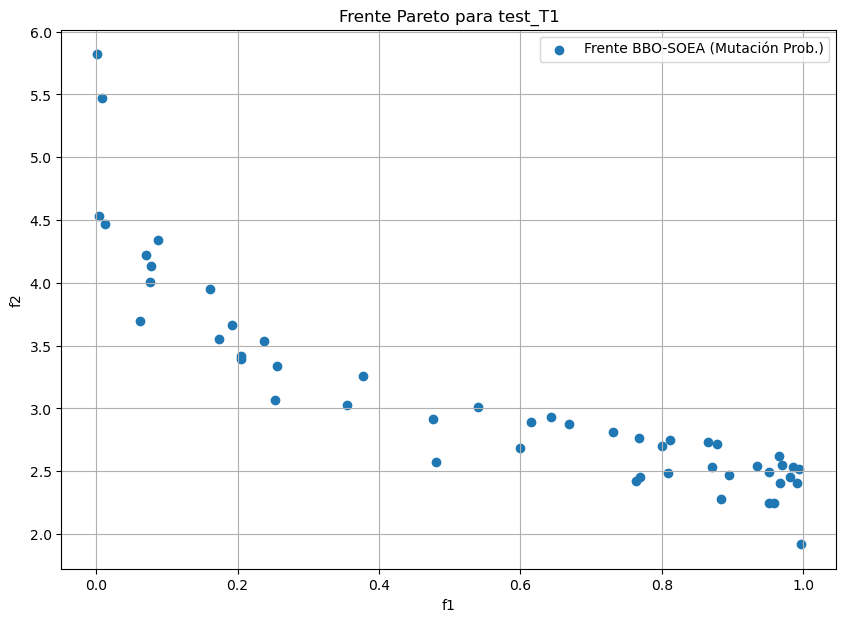

In [5]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---
TARGET_FUNCTION = test_T1
PROBLEM_TYPE = 'float'
M_VARS = 30
BOUNDS = [(0, 1)] * M_VARS
BIT_LENGTHS = None

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2
MAX_MIGRATION = 1.0
M_MAX = 0.05 # Tasa máxima de mutación (nuevo parámetro)

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO (con mutación probabilística) para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        m_max=M_MAX # Pasar el nuevo parámetro m_max
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA (Mutación Prob.)")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_2$ (No Convexa)

Ejecutando BBO (con mutación probabilística) para test_T2...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0

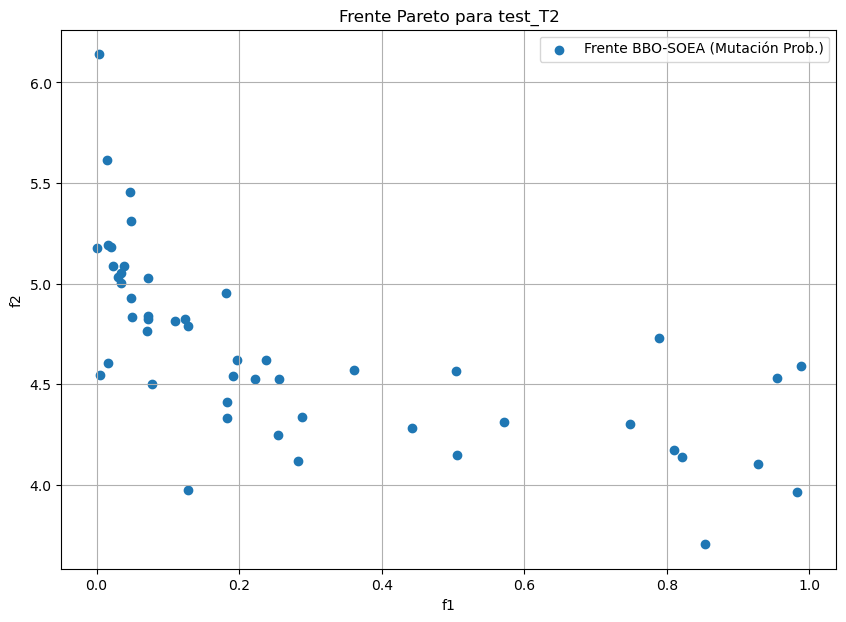

In [6]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---
TARGET_FUNCTION = test_T2
PROBLEM_TYPE = 'float'
M_VARS = 30
BOUNDS = [(0, 1)] * M_VARS
BIT_LENGTHS = None

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2
MAX_MIGRATION = 1.0
M_MAX = 0.05

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO (con mutación probabilística) para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        m_max=M_MAX 
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA (Mutación Prob.)")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_3$ (Discreta)

Ejecutando BBO (con mutación probabilística) para test_T3...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0

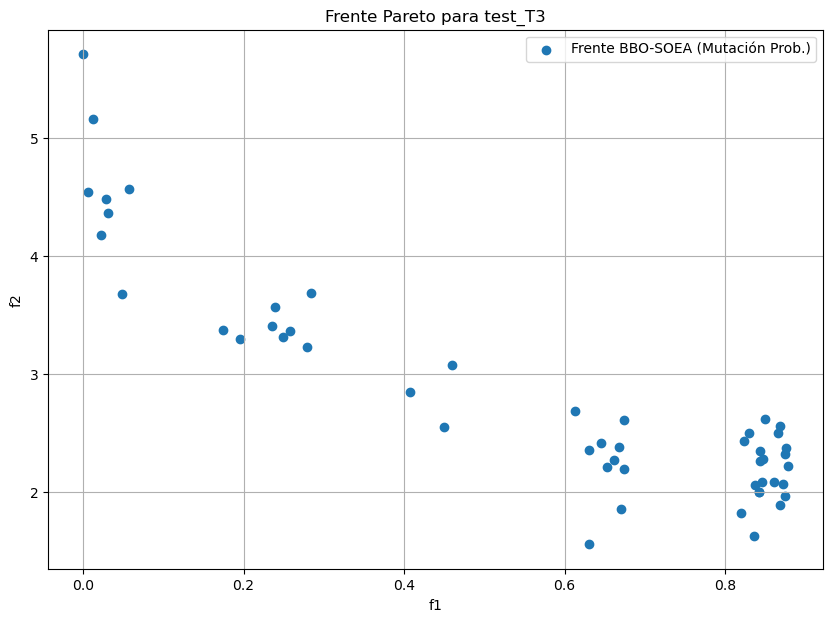

In [7]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---
TARGET_FUNCTION = test_T3
PROBLEM_TYPE = 'float'
M_VARS = 30
BOUNDS = [(0, 1)] * M_VARS
BIT_LENGTHS = None

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2
MAX_MIGRATION = 1.0
M_MAX = 0.05

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO (con mutación probabilística) para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        m_max=M_MAX
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA (Mutación Prob.)")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_4$ (Multimodal)

Ejecutando BBO (con mutación probabilística) para test_T4...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0

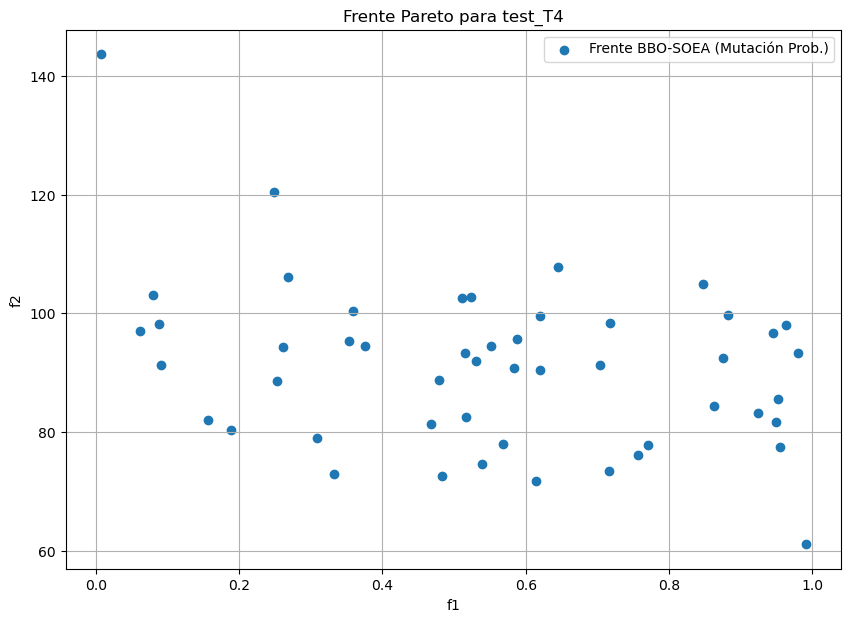

In [8]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---
TARGET_FUNCTION = test_T4
PROBLEM_TYPE = 'float'
M_VARS = 10
BOUNDS = [(0, 1)] + [(-5, 5)] * (M_VARS - 1)
BIT_LENGTHS = None

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2
MAX_MIGRATION = 1.0
M_MAX = 0.05

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO (con mutación probabilística) para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        m_max=M_MAX
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA (Mutación Prob.)")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_5$ (Deceptiva)

Ejecutando BBO (con mutación probabilística) para test_T5...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0

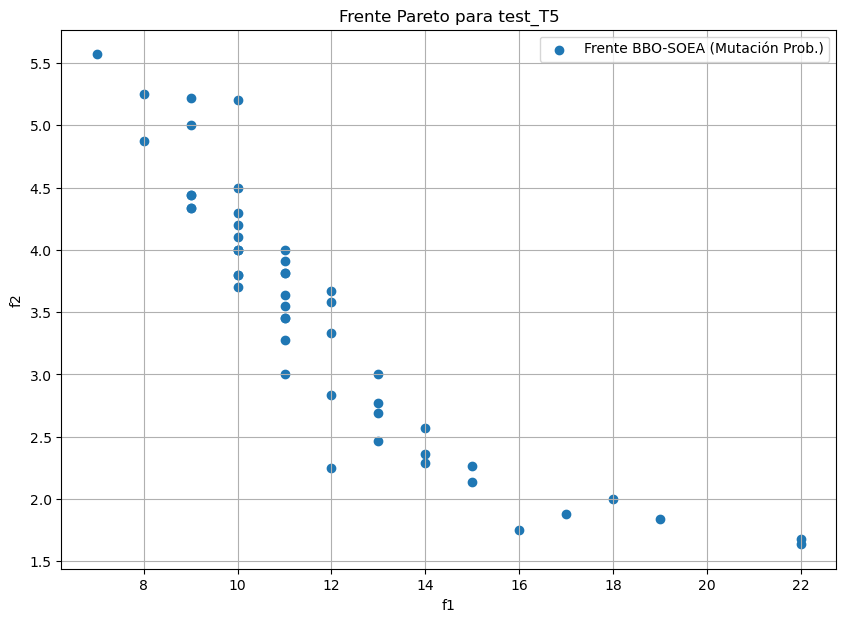

In [9]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---
TARGET_FUNCTION = test_T5
PROBLEM_TYPE = 'bits'
M_VARS = 11
BOUNDS = None
BIT_LENGTHS = [30] + [5] * 10

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2
MAX_MIGRATION = 1.0
M_MAX = 0.05 # Tasa máxima de mutación (nuevo parámetro)

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO (con mutación probabilística) para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        m_max=M_MAX # Pasar el nuevo parámetro m_max
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA (Mutación Prob.)")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Implementación Test $\mathcal{T}_6$ (No Uniforme)

Ejecutando BBO (con mutación probabilística) para test_T6...
  Ejecutando con pesos: w1=0.00, w2=1.00
  Ejecutando con pesos: w1=0.02, w2=0.98
  Ejecutando con pesos: w1=0.04, w2=0.96
  Ejecutando con pesos: w1=0.06, w2=0.94
  Ejecutando con pesos: w1=0.08, w2=0.92
  Ejecutando con pesos: w1=0.10, w2=0.90
  Ejecutando con pesos: w1=0.12, w2=0.88
  Ejecutando con pesos: w1=0.14, w2=0.86
  Ejecutando con pesos: w1=0.16, w2=0.84
  Ejecutando con pesos: w1=0.18, w2=0.82
  Ejecutando con pesos: w1=0.20, w2=0.80
  Ejecutando con pesos: w1=0.22, w2=0.78
  Ejecutando con pesos: w1=0.24, w2=0.76
  Ejecutando con pesos: w1=0.27, w2=0.73
  Ejecutando con pesos: w1=0.29, w2=0.71
  Ejecutando con pesos: w1=0.31, w2=0.69
  Ejecutando con pesos: w1=0.33, w2=0.67
  Ejecutando con pesos: w1=0.35, w2=0.65
  Ejecutando con pesos: w1=0.37, w2=0.63
  Ejecutando con pesos: w1=0.39, w2=0.61
  Ejecutando con pesos: w1=0.41, w2=0.59
  Ejecutando con pesos: w1=0.43, w2=0.57
  Ejecutando con pesos: w1=0.45, w2=0

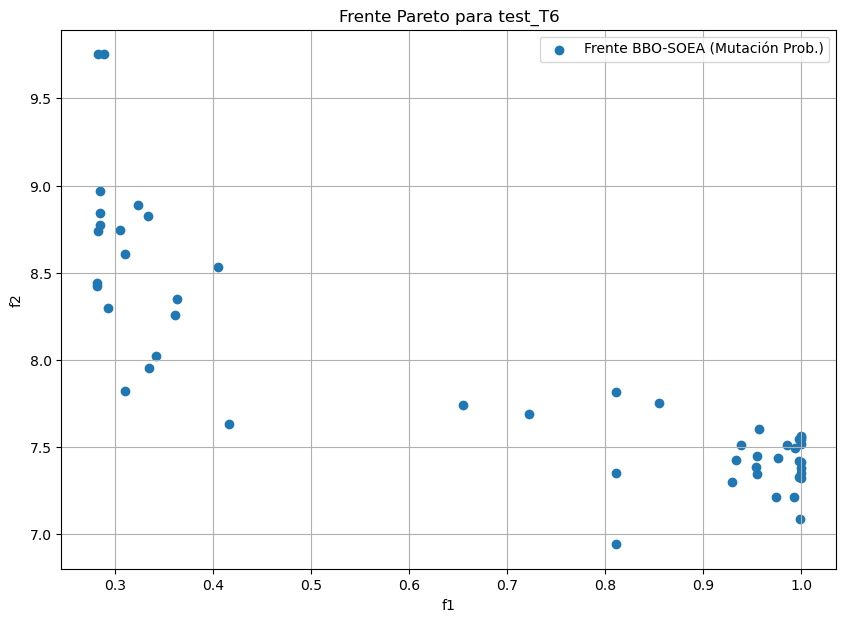

In [10]:
# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---
TARGET_FUNCTION = test_T6
PROBLEM_TYPE = 'float'
M_VARS = 10
BOUNDS = BOUNDS = [(0, 1)] * M_VARS
BIT_LENGTHS = None

# --- 2. HIPERPARÁMETROS DE BBO ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2
MAX_MIGRATION = 1.0
M_MAX = 0.05 # Tasa máxima de mutación (nuevo parámetro)

# --- 3. CONFIGURACIÓN DEL WRAPPER SOEA ---
N_PESOS = 50
pesos_list = np.linspace(0, 1, N_PESOS)

# --- 4. EJECUCIÓN ---
print(f"Ejecutando BBO (con mutación probabilística) para {TARGET_FUNCTION.__name__}...")
frente_pareto_f1 = []
frente_pareto_f2 = []

for w1 in pesos_list:
    w2 = 1.0 - w1
    weights = (w1, w2)
    print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")
    
    mejor_f1, mejor_f2 = run_bbo(
        test_function=TARGET_FUNCTION,
        problem_type=PROBLEM_TYPE,
        m=M_VARS,
        bounds=BOUNDS,
        bit_lengths=BIT_LENGTHS,
        pop_size=POP_SIZE,
        generations=GENERATIONS,
        weights=weights,
        max_migration=MAX_MIGRATION,
        elitism_param=ELITISM_PARAM,
        m_max=M_MAX # Pasar el nuevo parámetro m_max
    )
    
    frente_pareto_f1.append(mejor_f1)
    frente_pareto_f2.append(mejor_f2)

print("¡Ejecución completada!")

# --- 5. GRÁFICA DE RESULTADOS ---
plt.figure(figsize=(10, 7))
plt.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA (Mutación Prob.)")
plt.xlabel("f1")
plt.ylabel("f2")
plt.title(f"Frente Pareto para {TARGET_FUNCTION.__name__}")
plt.legend()
plt.grid(True)
plt.show()

Ejecutando BBO para T1 (Convexa)...
Ejecutando BBO para T2 (No Convexa)...
Ejecutando BBO para T3 (Discreta)...
Ejecutando BBO para T4 (Multimodal)...
Ejecutando BBO para T5 (Deceptiva)...
Ejecutando BBO para T6 (No Uniforme)...
¡Todas las ejecuciones completadas!


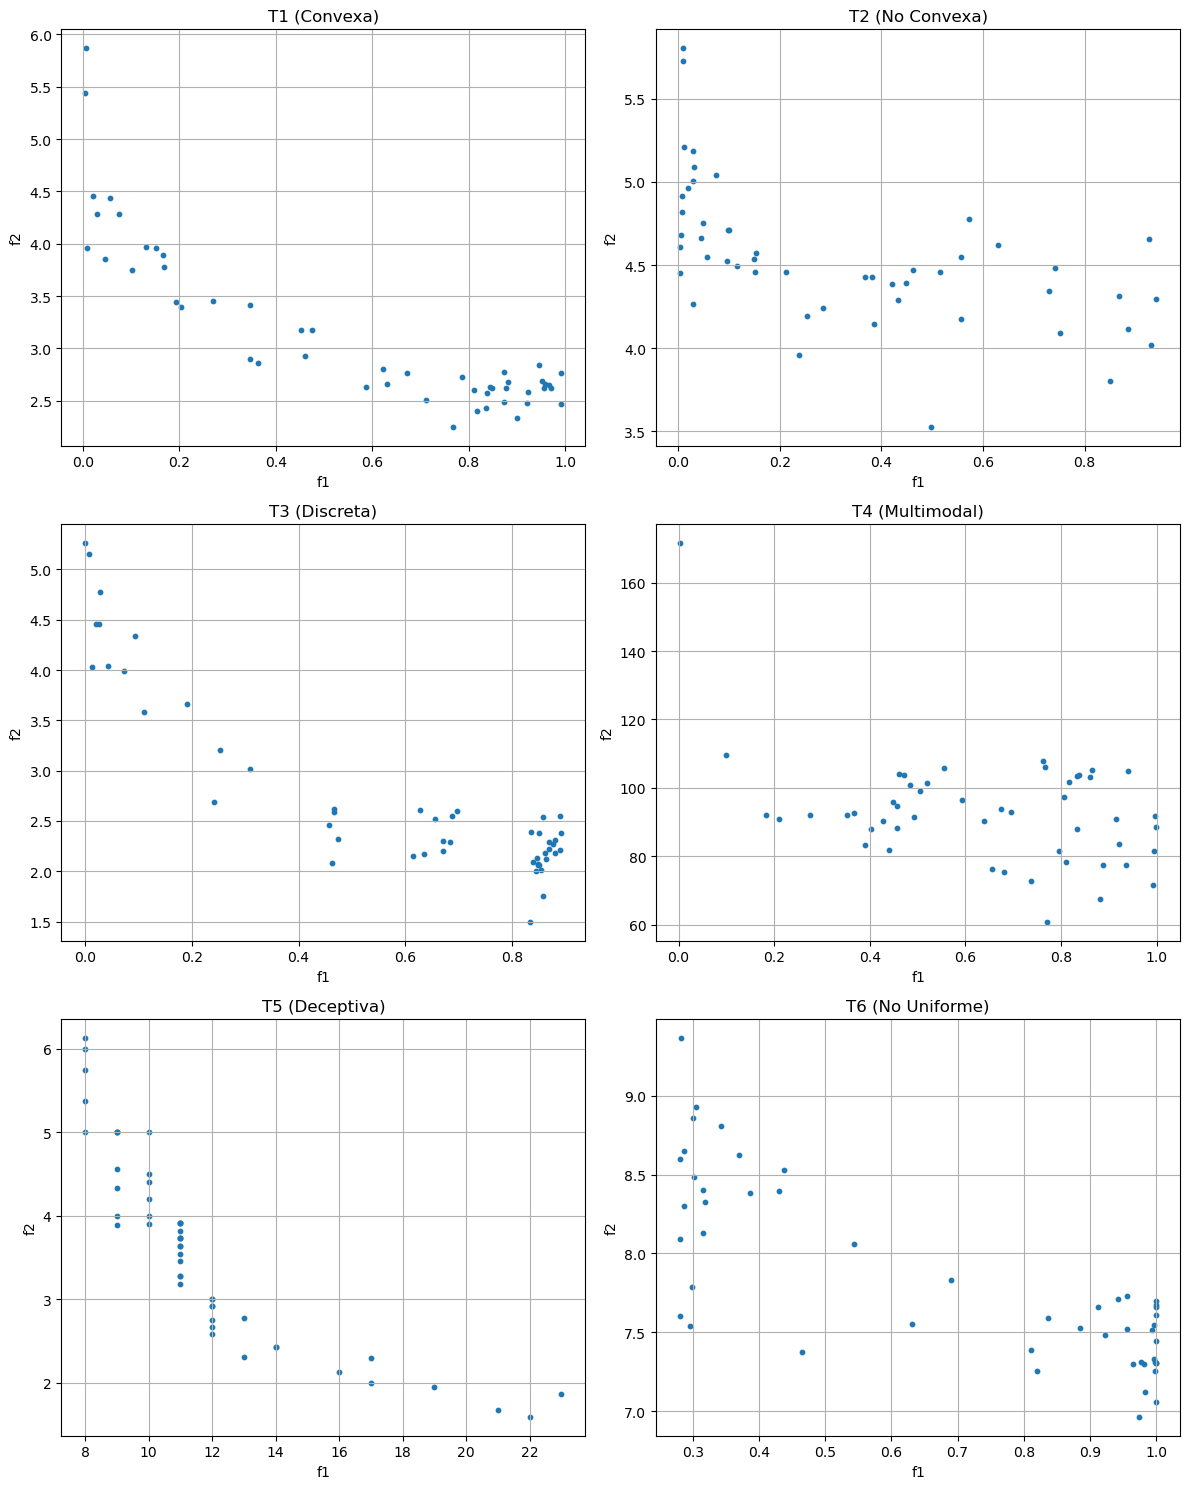

In [11]:
import matplotlib.pyplot as plt
import numpy as np
# ... (importa tus otras funciones y clases) ...

# --- Lista de configuraciones para cada test ---
test_configs = [
    {'func': test_T1, 'type': 'float', 'm': 30, 'bounds': [(0, 1)] * 30, 'bits': None, 'title': 'T1 (Convexa)'},
    {'func': test_T2, 'type': 'float', 'm': 30, 'bounds': [(0, 1)] * 30, 'bits': None, 'title': 'T2 (No Convexa)'},
    {'func': test_T3, 'type': 'float', 'm': 30, 'bounds': [(0, 1)] * 30, 'bits': None, 'title': 'T3 (Discreta)'},
    {'func': test_T4, 'type': 'float', 'm': 10, 'bounds': [(0, 1)] + [(-5, 5)] * 9, 'bits': None, 'title': 'T4 (Multimodal)'},
    {'func': test_T5, 'type': 'bits', 'm': 11, 'bounds': None, 'bits': [30] + [5] * 10, 'title': 'T5 (Deceptiva)'},
    {'func': test_T6, 'type': 'float', 'm': 10, 'bounds': [(0, 1)] * 10, 'bits': None, 'title': 'T6 (No Uniforme)'}
]

# --- Hiperparámetros (iguales para todos) ---
POP_SIZE = 50
GENERATIONS = 100
ELITISM_PARAM = 2
MAX_MIGRATION = 1.0
M_MAX = 0.05
N_PESOS = 50
pesos_list = np.linspace(0, 1, N_PESOS)

# --- Crear la figura con subplots 3x2 ---
fig, axes = plt.subplots(3, 2, figsize=(12, 15)) # Ajusta figsize según necesites
axes = axes.flatten() # Convierte la matriz de ejes en una lista

# --- Bucle principal ---
for i, config in enumerate(test_configs):
    print(f"Ejecutando BBO para {config['title']}...")
    frente_pareto_f1 = []
    frente_pareto_f2 = []

    for w1 in pesos_list:
        w2 = 1.0 - w1
        weights = (w1, w2)
        # (Opcional: puedes quitar el print interno para que no sea tan verboso)
        # print(f"  Ejecutando con pesos: w1={w1:.2f}, w2={w2:.2f}")

        mejor_f1, mejor_f2 = run_bbo(
            test_function=config['func'],
            problem_type=config['type'],
            m=config['m'],
            bounds=config['bounds'],
            bit_lengths=config['bits'],
            pop_size=POP_SIZE,
            generations=GENERATIONS,
            weights=weights,
            max_migration=MAX_MIGRATION,
            elitism_param=ELITISM_PARAM,
            m_max=M_MAX
        )
        frente_pareto_f1.append(mejor_f1)
        frente_pareto_f2.append(mejor_f2)

    # --- Dibujar en el subplot correspondiente ---
    ax = axes[i]
    ax.scatter(frente_pareto_f1, frente_pareto_f2, label="Frente BBO-SOEA", s=10) # s=10 para puntos más pequeños
    ax.set_xlabel("f1")
    ax.set_ylabel("f2")
    ax.set_title(config['title'])
    ax.grid(True)
    # ax.legend() # Puedes quitar la leyenda individual si es redundante

print("¡Todas las ejecuciones completadas!")

# --- Ajustar layout y guardar/mostrar la figura completa ---
plt.tight_layout() # Ajusta espacios entre subplots
plt.savefig("resultados_bbo_3x2.png") # Guarda la imagen
plt.show()